<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-02/trabalho-02/demoD1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from typing import NewType, List
import numpy as np
import matplotlib.pyplot as plt
import math
import statistics

# Tipo para representar cada ponto: um registro com features float
Point = NewType("Point", tuple[float, ...])

def dist(p: Point, q: Point) -> float:
  soma = 0
  for i in range(len(p)):
      # Calcula a diferença para cada feature
      soma += (p[i] - q[i]) ** 2

  return math.sqrt(soma)


def normalizacao(x: np.ndarray) -> np.ndarray:
  # Pega os valores mínimos e máximos de cada feature
  mins = np.min(x, axis=0)
  maxs = np.max(x, axis=0)

  denom = maxs - mins # max(xi) - min(xi)
  denom[denom == 0] = 1

  return mins, denom

def aplicaNormalizacao(x: np.ndarray, mins: np.ndarray, denom: np.ndarray) -> np.ndarray:
  return (x - mins) / denom

def getDadosRotulo(dados: np.ndarray, rotulos: np.ndarray, rotulo: int, indice: int) -> List[int]:
    ret = []
    for idx in range(0, len(dados)):
        if(rotulos[idx] == rotulo):
            ret.append(dados[idx][indice])
    return ret

def visualizaPontos(dados: np.ndarray, rotulos: np.ndarray, d1: int, d2: int):
    fig, ax = plt.subplots()

    ax.scatter(getDadosRotulo(dados, rotulos, 1, d1), getDadosRotulo(dados, rotulos, 1, d2), c='red' , marker='^')
    ax.scatter(getDadosRotulo(dados, rotulos, 2, d1), getDadosRotulo(dados, rotulos, 2, d2), c='blue' , marker='+')
    ax.scatter(getDadosRotulo(dados, rotulos, 3, d1), getDadosRotulo(dados, rotulos, 3, d2), c='green', marker='.')

    plt.show()

def meuKnn(dadosTrain: np.ndarray, rotuloTrain: np.ndarray, dadosTeste: np.ndarray, k: int) -> np.ndarray:
  # Extrai número de registros do conjunto de train e test
  trainLength = dadosTrain.shape[0]
  testLength = dadosTeste.shape[0]

  # Cria matriz de distâncias com dimensão nº de linhas de teste X nº de linhas de treino
  distances = np.ndarray(shape=(testLength, trainLength))
  predictions = np.zeros(shape=(testLength))

  for row in range(testLength):
    for col in range(trainLength):
      distances[row, col] = dist(dadosTeste[row], dadosTrain[col])

    # Armazena (distancia, rotulo) para todos os vizinhos
    closest_neighbors = [
        (v, rotuloTrain[i])
        for i, v in enumerate(distances[row])
    ]

    # Ordena os vizinhos pelo valor da distância
    closest_neighbors.sort(key=lambda x: x[0])

    # Mantém apenas os K vizinhos mais próximos
    predictions[row] = statistics.mode(
        [rot for (_, rot) in closest_neighbors[:k]]
    )

  return predictions


def calculaAcuracia(predicted_labels, test_labels):
  is_correct = [1 for i in range(len(test_labels)) if test_labels[i] == predicted_labels[i]]
  correct_total = sum(is_correct)
  total = len(test_labels)

  accuracy = correct_total / total
  return accuracy

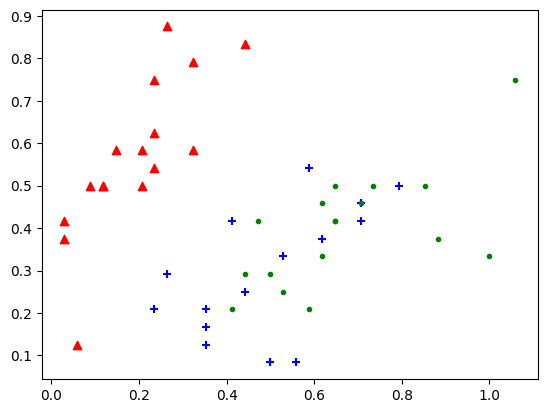

In [7]:
from scipy.io import loadmat

LABELS = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]
FEATURES = ["LS", "CS", "LP", "CP"]

# Lê o dataset
data = loadmat('grupoDados1.mat')

# Faz escala contando com treino e teste
min_vals, denom = normalizacao(data['grupoTrain'])

# Ajusta os valores ao filtro normalizado
test_set = aplicaNormalizacao(data['grupoTest'], min_vals, denom)
train_set = aplicaNormalizacao(data['grupoTrain'], min_vals, denom)

# Normaliza rótulos de treino e teste como ndarray
train_labels = np.ravel(data['trainRots'])
test_labels = np.ravel(data['testRots'])

# Retorna previsão de rótulo para cada dado de teste
predicted_labels = meuKnn(train_set, train_labels, test_set, 1)

# Plota rótulos da previsão no gráfico
visualizaPontos(test_set, predicted_labels, 0, 1)

### 1. Qual é a acurácia máxima que você consegue da classificação?

---

A acurácia máxima obtida é de 96%.

In [8]:
# Calcula acurácia da previsão
accuracy = calculaAcuracia(predicted_labels, test_labels)
print(f"Acurácia: {accuracy}")

Acurácia: 0.96


### 2. É necessário ter todas as características (atributos) para obter a acurácia máxima para esta classificação?

---

Não, como os testes de força bruta evidenciam, duas combinações de feature permitiram alcançar a acurácia máxima de 96%: com as 4 features e com todas menos a "LP". Como a sua remoção não muda a acurácia, ela pode ser interpretada como uma característica redundante ou irrelevante para a classificação.

In [9]:
import itertools

# Recupera nº de features através no nº de colunas do conjunto de treino
num_features = train_set.shape[1]

# Gera todas as possíveis combinações para o número de features
combinations = []
for r in range(1, num_features + 1):
    combinations.extend(itertools.combinations(range(num_features), r))

results = []
for comb in combinations:
    # Seleciona apenas as features da combinação
    train_subset = train_set[:, comb]
    test_subset = test_set[:, comb]

    # Faz o cálculo do KNN para cada combinação
    predicted = meuKnn(train_subset, train_labels, test_subset, 1)

    # Calcula a acurácia da previsão
    acc = calculaAcuracia(predicted, test_labels)

    results.append((comb, acc))

results.sort(key=lambda x: x[1], reverse=True)

# Imprime a combinação usada e sua respectiva acurácia
for comb, acc in results:
    feature_names = [FEATURES[i] for i in comb]
    print(f"{feature_names} -> {acc}")

['LS', 'CS', 'CP'] -> 0.96
['LS', 'CS', 'LP', 'CP'] -> 0.96
['LS', 'LP'] -> 0.94
['LP', 'CP'] -> 0.94
['LS', 'LP', 'CP'] -> 0.94
['CS', 'LP', 'CP'] -> 0.94
['LP'] -> 0.92
['LS', 'CP'] -> 0.92
['LS', 'CS', 'LP'] -> 0.92
['CS', 'LP'] -> 0.9
['CS', 'CP'] -> 0.88
['CP'] -> 0.84
['LS', 'CS'] -> 0.68
['LS'] -> 0.56
['CS'] -> 0.5
